In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os

from core.dataset import FilteredMNIST
from core.models.vae import VAE_model
from core.utils import extract_representation, plot_latent_space, plot_input_space, sample_per_class
from core.clustering import kmeans_euclidean, kmeans_riemannian, plot_clustering_boundary

# Load dataset

In [2]:
# MNIST Dataset transformation
mnist_transform = transforms.Compose([
    transforms.ToTensor(), # Converts to [0, 1] interval
    transforms.Lambda(lambda x: torch.flatten(x)) # Flattens the image to a 1D vector
])

# Download and load the MNIST dataset
full_train_dataset = datasets.MNIST(root='mnist_data', train=True, transform=mnist_transform, download=True)
print("Original size of the dataset: ", len(full_train_dataset))
filtered_labels = [0, 1, 6]
print("Filtered labels: ", filtered_labels)
train_dataset = FilteredMNIST(full_train_dataset, filtered_labels)
print("New size of the dataset: ", len(train_dataset))

batch_size = 256
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True,num_workers=4)

Original size of the dataset:  60000
Filtered labels:  [0, 1, 6]
New size of the dataset:  18583


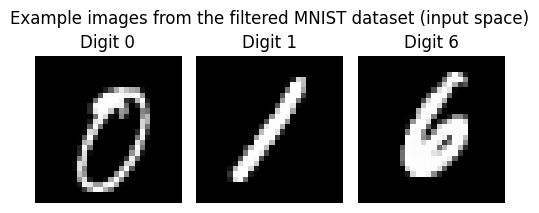

In [3]:
plot_input_space(train_loader, filtered_labels)

# Load VAE

In [4]:
# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Construct an artificial dataset
N_train, D = 17714, 28 * 28  # Number of training samples and dimensionality of the input

# Parameters of the VAE
d = 2  # The latent space dimension
activFun = nn.LeakyReLU(0.2)
H = 128
lambda_reg = 1e-7  # For the weights of the networks
epochs = 500
learning_rate = 2e-4
clipping_value = 1
batch_size = 128
r_max = 1  # au lieu de 1.0
warmup = int(0.5 * epochs)

In [5]:
# The model and the optimizer for the VAE
model = VAE_model(d, D, H, activFun).to(device)
optimizer_model = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=lambda_reg)

In [6]:
# if model already exists, load it
model_path = "saved_models/vae_model_mnist_016_withvar.pt"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print(f"Model loaded from {model_path}")

Model loaded from saved_models/vae_model_mnist_016_withvar.pt


In [7]:
# Extract the latent representations for the training data
Z, labels = extract_representation(model, train_loader, device)

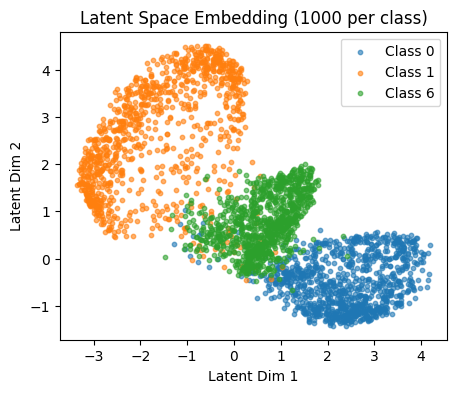

In [8]:
plot_latent_space(Z, labels)

In [9]:
# Euclidean clustering
Z_sub, labels_sub = sample_per_class(Z, labels, 1000)

f1_euclid, pred_eucl = kmeans_euclidean(Z_sub.numpy(), labels_sub.numpy())
f1_riem, pred_riem = kmeans_riemannian(Z_sub.to(device), labels_sub.to(device), model)

print("Euclidean F1:", f1_euclid)
print("Riemannian F1:", f1_riem)

Precomputing M...


/home/infres/court-22/miniconda3/lib/python3.12/site-packages/torch/autograd/graph.py:744: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /opt/conda/conda-bld/pytorch_1716905969118/work/aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Done.
Euclidean F1: 0.9283200028615882
Riemannian F1: 0.9424394058602937


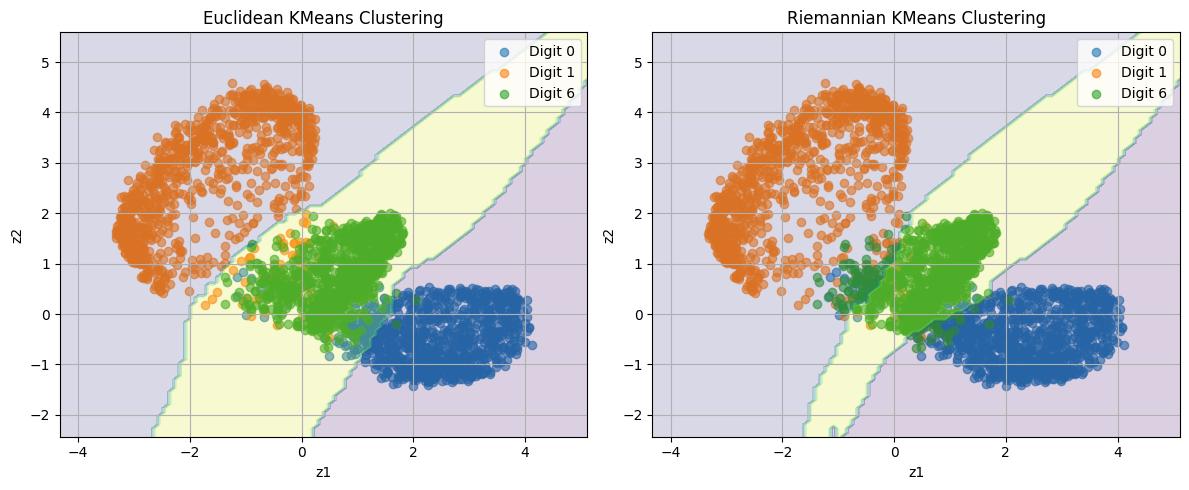

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_clustering_boundary(
    Z_sub.cpu().numpy(),
    labels_sub.cpu().numpy(),
    pred_eucl,
    axes[0],
    "Euclidean KMeans Clustering"
)

plot_clustering_boundary(
    Z_sub.cpu().numpy(),
    labels_sub.cpu().numpy(),
    pred_riem,
    axes[1],
    "Riemannian KMeans Clustering"
)

plt.tight_layout()
plt.show()